# Analisi copy number Wakhan per gene

Parsing dei VCF di segmenti CNA prodotti da Wakhan e controllo dello stato del copy number
per una lista di geni (default: pannello GBM in `wakhan_utils.DEFAULT_GENE_BED`).

In [1]:
from wakhan_utils import (
    annotate_genes_cn,
    annotate_genes_cn_multi,
    plot_gene_cn_heatmap,
    load_gene_regions,
)

## Singolo campione

In [2]:
vcf_path = (
    "/CTGlab/projects/GBM/seqperglio/lumos/wakhan/GSC11/wakhan_cna/"
    "solution_1/vcf_output/Sample_3.44_0.87_0.91_wakhan_cna_integers.vcf"
)

ann = annotate_genes_cn(vcf_path)
ann[["gene", "chr", "start", "end", "seg_type", "alt", "tcn", "cn1", "cn2", "overlap_bp"]]

,gene,chr,start,end,seg_type,alt,tcn,cn1,cn2,overlap_bp
0,CDK4,chr12,53446063,63305010,GAIN,<DUP>,4.0,2.0,2.0,8286
1,CDK6,chr7,80914433,100972320,GAIN,<DUP>,4.0,3.0,1.0,231652
2,CDKN2A,chr9,19836543,23295791,LOSS,<DEL>,0.0,0.0,0.0,27549
3,CDKN2B,chr9,19836543,23295791,LOSS,<DEL>,0.0,0.0,0.0,6402
4,EGFR,chr7,55012669,55076639,LOSS,<DEL>,0.0,0.0,0.0,57622
5,EGFR,chr7,55076639,55126425,LOSS,<DEL>,0.0,0.0,0.0,49786
6,EGFR,chr7,55126425,55163726,LOSS,<DEL>,0.0,0.0,0.0,37301
7,EGFR,chr7,55163726,55201250,GAIN,<DUP>,8.0,3.0,5.0,37524
8,EGFR,chr7,55201250,55281652,GAIN,<DUP>,5.0,1.0,4.0,10378
9,FGFR1,chr8,37729143,43000000,GAIN,<DUP>,3.0,1.0,2.0,68619


## Confronto tra più soluzioni/campioni

Esempio: confronto tra due soluzioni Wakhan (diverse stime di purezza/ploidia) per lo stesso campione.

In [3]:
vcf_paths = {
    "solution_1.integers": (
        "/CTGlab/projects/GBM/seqperglio/lumos/wakhan/GSC11/wakhan_cna/"
        "solution_1/vcf_output/Sample_3.44_0.87_0.91_wakhan_cna_integers.vcf"
    ),
    "solution_1.subclonals": (
        "/CTGlab/projects/GBM/seqperglio/lumos/wakhan/GSC11/wakhan_cna/"
        "solution_1/vcf_output/Sample_3.44_0.87_0.91_wakhan_cna_subclonals.vcf"
    ),
}

df = annotate_genes_cn_multi(vcf_paths)
df[["sample", "gene", "seg_type", "tcn", "cn1", "cn2"]]

,sample,gene,seg_type,tcn,cn1,cn2
0,solution_1.integers,CDK4,GAIN,4.0,2.0,2.0
1,solution_1.integers,CDK6,GAIN,4.0,3.0,1.0
2,solution_1.integers,CDKN2A,LOSS,0.0,0.0,0.0
3,solution_1.integers,CDKN2B,LOSS,0.0,0.0,0.0
4,solution_1.integers,EGFR,LOSS,0.0,0.0,0.0
5,solution_1.integers,EGFR,LOSS,0.0,0.0,0.0
6,solution_1.integers,EGFR,LOSS,0.0,0.0,0.0
7,solution_1.integers,EGFR,GAIN,8.0,3.0,5.0
8,solution_1.integers,EGFR,GAIN,5.0,1.0,4.0
9,solution_1.integers,FGFR1,GAIN,3.0,1.0,2.0


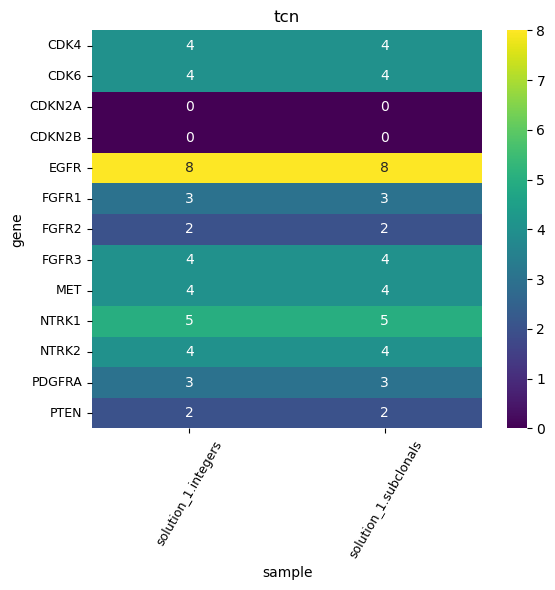

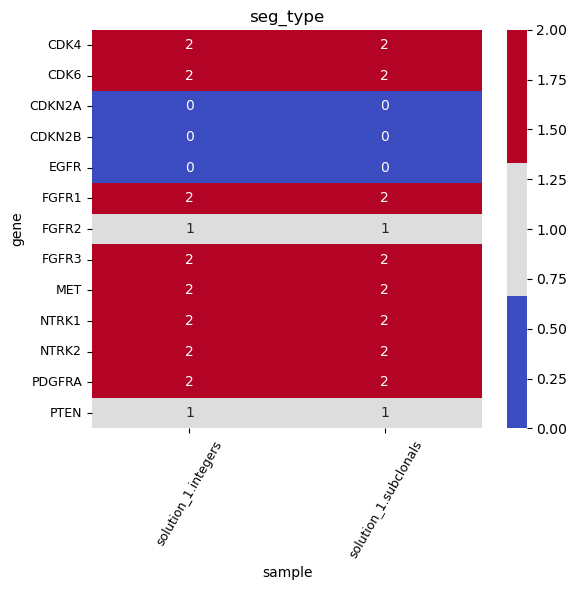

In [4]:
plot_gene_cn_heatmap(df, value="tcn")
plot_gene_cn_heatmap(df, value="seg_type")

## Gene list personalizzata

Per controllare geni diversi dal pannello di default, passare un BED custom (`chr, start, end, gene`) a `gene_bed=`.

In [ ]:
# custom_ann = annotate_genes_cn(vcf_path, gene_bed="my_genes.bed")